In [1]:
#Install & Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
import statsmodels.api as sm
from imblearn.over_sampling import RandomOverSampler, SMOTE
import geopandas as gpd # Uncomment if you need geopandas and have it installed

In [2]:
DATA_PATH = 'C:/Users/BASHEER-PC/OneDrive/Desktop/Weather Housing Analysis Project/Streamlit app/'

In [3]:
# --- 1. Load & Clean StatCan Average Rents ---
print("Loading and Cleaning StatCan Average Rents...")
df_rents = pd.DataFrame() # Initialize as empty
rents_path = f'{DATA_PATH}3410013301_databaseLoadingData.csv' # Corrected: defined here
try:
    df_rents_raw = pd.read_csv(rents_path)
    # Fill missing 'VALUE' using median per 'GEO' and 'Type of unit' before any date processing
    df_rents_raw['VALUE'] = df_rents_raw.groupby(['GEO', 'Type of unit'])['VALUE'].transform(lambda x: x.fillna(x.median()))

    # Convert REF_DATE to integer year first, then to datetime (e.g., 2018 -> 2018-01-01)
    df_rents_raw['year'] = df_rents_raw['REF_DATE'].astype(int)
    df_rents_raw['REF_DATE'] = pd.to_datetime(df_rents_raw['year'], format='%Y')

    # Drop specified columns
    cols_to_drop_rents = ['SYMBOL', 'TERMINATED', 'STATUS', 'DECIMALS']
    df_rents_raw.drop(columns=cols_to_drop_rents, inplace=True, errors='ignore')

    # Standardize city names and rename 'GEO' to 'city'
    df_rents_raw['GEO'] = df_rents_raw['GEO'].replace({
        'Vancouver, British Columbia': 'Vancouver',
        'Toronto, Ontario': 'Toronto',
        'Calgary, Alberta': 'Calgary'
    })
    df_rents_raw.rename(columns={'GEO': 'city'}, inplace=True)

    # Expand yearly rent data to monthly data
    min_year = df_rents_raw['year'].min()
    max_year = df_rents_raw['year'].max()
    all_months = pd.MultiIndex.from_product([
        df_rents_raw['city'].unique(),
        df_rents_raw['Type of unit'].unique(),
        range(min_year, max_year + 1),
        range(1, 13)
    ], names=['city', 'Type of unit', 'year', 'month']).to_frame(index=False)

    # Merge original yearly rents with the new monthly framework
    df_rents = pd.merge(all_months, df_rents_raw[['city', 'Type of unit', 'year', 'VALUE']],
                                on=['city', 'Type of unit', 'year'],
                                how='left')

    # Forward fill and backward fill 'VALUE' to propagate yearly rent to all months
    df_rents['VALUE'] = df_rents.groupby(['city', 'Type of unit'])['VALUE'].fillna(method='ffill')
    df_rents['VALUE'] = df_rents.groupby(['city', 'Type of unit'])['VALUE'].fillna(method='bfill')

    # Drop any rows where VALUE is still NaN (shouldn't happen if ffill/bfill works on groups)
    df_rents.dropna(subset=['VALUE'], inplace=True)

    print("StatCan Average Rents loaded and cleaned.")
    print(df_rents[['city', 'year', 'month', 'Type of unit', 'VALUE']].head())
except FileNotFoundError:
    print(f"Error: StatCan Average Rents file not found at {rents_path}. df_rents will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing StatCan Average Rents: {e}. df_rents will be empty.")
print("-" * 50)

Loading and Cleaning StatCan Average Rents...
StatCan Average Rents loaded and cleaned.
      city  year  month    Type of unit   VALUE
0  Toronto  2018      1  Bachelor units  1081.0
1  Toronto  2018      1  Bachelor units  1217.0
2  Toronto  2018      1  Bachelor units  1080.0
3  Toronto  2018      1  Bachelor units  1083.0
4  Toronto  2018      2  Bachelor units  1081.0
--------------------------------------------------


C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\159800819.py:42: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df_rents['VALUE'] = df_rents.groupby(['city', 'Type of unit'])['VALUE'].fillna(method='ffill')
C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\159800819.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rents['VALUE'] = df_rents.groupby(['city', 'Type of unit'])['VALUE'].fillna(method='ffill')
C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\159800819.py:43: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead


In [4]:
# --- 2. Load & Clean Weather Data (for Vancouver, Toronto, Calgary) ---
print("Loading and Cleaning Weather Data...")
monthly_weather = pd.DataFrame() # Initialize as empty
def load_and_clean_weather(city_name, ids, data_path):
    files = [f"{data_path}en_climate_daily_{ids}_{y}_P1D.csv" for y in range(2018, 2025)]
    df_list = []
    for f in files:
        try:
            temp_df = pd.read_csv(f)
            temp_df['Date/Time'] = pd.to_datetime(temp_df['Date/Time'], errors='coerce')
            temp_df['year'] = temp_df['Date/Time'].dt.year
            temp_df['month'] = temp_df['Date/Time'].dt.month
            temp_df['city'] = city_name

            relevant_columns = ['Date/Time', 'year', 'month', 'city', 'Max Temp (°C)', 'Min Temp (°C)', 'Total Precip (mm)', 'Total Snow (cm)','Mean Temp (°C)']
            temp_df = temp_df[relevant_columns].copy()
            df_list.append(temp_df)
        except FileNotFoundError:
            # print(f"File not found: {f}") # Commented out to reduce console spam
            continue
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

try:
    vancouver_weather = load_and_clean_weather("Vancouver", "BC_1108395", DATA_PATH)
    toronto_weather = load_and_clean_weather("Toronto", "ON_6158731", DATA_PATH)
    calgary_weather = load_and_clean_weather("Calgary", "AB_3031092", DATA_PATH)
    weather_data_raw = pd.concat([vancouver_weather, toronto_weather, calgary_weather])

    if not weather_data_raw.empty:
        # Handle missing values for daily weather: fill precip/snow with 0, temps with city mean
        weather_data_raw['Max Temp (°C)'] = weather_data_raw.groupby('city')['Max Temp (°C)'].transform(lambda x: x.fillna(x.mean()))
        weather_data_raw['Min Temp (°C)'] = weather_data_raw.groupby('city')['Min Temp (°C)'].transform(lambda x: x.fillna(x.mean()))
        weather_data_raw['Total Precip (mm)'] = weather_data_raw.groupby('city')['Total Precip (mm)'].transform(lambda x: x.fillna(0))
        weather_data_raw['Total Snow (cm)'] = weather_data_raw.groupby('city')['Total Snow (cm)'].transform(lambda x: x.fillna(0))
        weather_data_raw['Mean Temp (°C)'] = weather_data_raw.groupby('city')['Mean Temp (°C)'].transform(lambda x: x.fillna(x.mean()))

        # Aggregate monthly weather: Sum precip/snow, Mean temps
        monthly_weather = weather_data_raw.groupby(['city', 'year', 'month']).agg(
            Avg_Max_Temp=('Max Temp (°C)', 'mean'),
            Avg_Min_Temp=('Min Temp (°C)', 'mean'),
            Total_Precip_mm=('Total Precip (mm)', 'sum'),
            Total_Snow_cm=('Total Snow (cm)', 'sum'),
            Avg_Mean_Temp=('Mean Temp (°C)', 'mean')
        ).reset_index()
        print("Weather Data loaded and cleaned.")
        print(monthly_weather.head())
    else:
        print("No weather data loaded. monthly_weather will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing Weather Data: {e}. monthly_weather will be empty.")
print("-" * 50)

Loading and Cleaning Weather Data...
Weather Data loaded and cleaned.
      city  year  month  Avg_Max_Temp  Avg_Min_Temp  Total_Precip_mm  \
0  Calgary  2018      1     -0.070968    -12.219799              8.5   
1  Calgary  2018      2     -5.875000    -17.243349             37.8   
2  Calgary  2018      3      0.138710    -10.383871             35.3   
3  Calgary  2018      4      7.380000     -4.223333             29.7   
4  Calgary  2018      5     21.125806      6.873305             32.5   

   Total_Snow_cm  Avg_Mean_Temp  
0           11.0      -5.871113  
1           43.3     -11.046589  
2           41.9      -5.141935  
3           24.8       1.586667  
4            0.0      13.738419  
--------------------------------------------------


In [5]:
# --- 3. Load & Clean Vancouver Rental Standards ---
print("Loading and Cleaning Vancouver Rental Standards...")
vancouver_issues = pd.DataFrame() # Initialize as empty
vancouver_issues_path = f'{DATA_PATH}rental-standards-current-issues.xlsx' # Corrected: defined here
try:
    vancouver_issues_raw = pd.read_excel(vancouver_issues_path)

    # Clean column names
    vancouver_issues_raw.columns = vancouver_issues_raw.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True).str.lower()

    # Handle missing values in 'totalunits' before calculating violation_rate
    vancouver_issues_raw['totalunits'] = vancouver_issues_raw['totalunits'].fillna(vancouver_issues_raw['totalunits'].median())

    # Fill missing 'businessoperator' with 'Unknown'
    vancouver_issues_raw['businessoperator'] = vancouver_issues_raw['businessoperator'].fillna('Unknown')

    # Drop rows with missing geographical data ('geom', 'geolocalarea', 'geo_point_2d')
    vancouver_issues = vancouver_issues_raw.dropna(subset=['geom', 'geolocalarea', 'geo_point_2d']).copy()

    # Calculate violation_rate
    vancouver_issues['violation_rate'] = vancouver_issues['totaloutstanding'] / (vancouver_issues['totalunits'] + 1e-6)

    # Add a city column and standardize the city name for Vancouver
    vancouver_issues['city'] = 'Vancouver'
    print("Vancouver Rental Standards loaded and cleaned.")
    print(vancouver_issues[['geolocalarea', 'totaloutstanding', 'totalunits', 'violation_rate','city']].head())
except FileNotFoundError:
    print(f"Error: Vancouver Rental Standards file not found at {vancouver_issues_path}. vancouver_issues will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing Vancouver Rental Standards: {e}. vancouver_issues will be empty.")
print("-" * 50)

Loading and Cleaning Vancouver Rental Standards...
Vancouver Rental Standards loaded and cleaned.
  geolocalarea  totaloutstanding  totalunits  violation_rate       city
0     Downtown                 5        71.0        0.070423  Vancouver
1     Downtown                 1       108.0        0.009259  Vancouver
2     Downtown                 1        60.0        0.016667  Vancouver
3     Downtown                 1       109.0        0.009174  Vancouver
4     Downtown                 2       125.0        0.016000  Vancouver
--------------------------------------------------


In [6]:
# --- 4. Load & Clean CMHC Mortgage Lending Rate ---
print("Loading and Cleaning CMHC Mortgage Lending Rate...")
mortgage_lending = pd.DataFrame() # Initialize as empty
mortgage_lending_path = f'{DATA_PATH}3410014501_databaseLoadingData.csv' # Corrected: defined here
try:
    mortgage_lending_raw = pd.read_csv(mortgage_lending_path)

    # Clean column names
    mortgage_lending_raw.columns = mortgage_lending_raw.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True).str.lower()

    # Convert 'ref_date' to datetime directly (handles YYYY and YYYY-MM)
    mortgage_lending_raw['ref_date'] = pd.to_datetime(mortgage_lending_raw['ref_date'], errors='coerce')

    # Extract year and month
    mortgage_lending_raw['year'] = mortgage_lending_raw['ref_date'].dt.year
    mortgage_lending_raw['month'] = mortgage_lending_raw['ref_date'].dt.month

    # Drop original 'ref_date' and status columns
    mortgage_lending_raw.drop(columns=['ref_date', 'status', 'symbol', 'terminated'], inplace=True, errors='ignore')

    # Rename 'value' to 'mortgage_rate' for clarity
    mortgage_lending = mortgage_lending_raw.rename(columns={'value': 'mortgage_rate'}).copy()

    # Handle missing mortgage rates if any, e.g., using forward fill then backward fill
    mortgage_lending['mortgage_rate'].fillna(method='ffill', inplace=True)
    mortgage_lending['mortgage_rate'].fillna(method='bfill', inplace=True)

    print("CMHC Mortgage Lending Rate loaded and cleaned.")
    print(mortgage_lending.head())
except FileNotFoundError:
    print(f"Error: CMHC Mortgage Lending Rate file not found at {mortgage_lending_path}. mortgage_lending will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing CMHC Mortgage Lending Rate: {e}. mortgage_lending will be empty.")
print("-" * 50)

Loading and Cleaning CMHC Mortgage Lending Rate...
CMHC Mortgage Lending Rate loaded and cleaned.
      geo           dguid      uom  uom_id scalar_factor  scalar_id   vector  \
0  Canada  2016A000011124  Percent     239         units          0  v733833   
1  Canada  2016A000011124  Percent     239         units          0  v733833   
2  Canada  2016A000011124  Percent     239         units          0  v733833   
3  Canada  2016A000011124  Percent     239         units          0  v733833   
4  Canada  2016A000011124  Percent     239         units          0  v733833   

   coordinate  mortgage_rate  decimals  year  month  
0           1           4.38         2  2018     11  
1           1           4.59         2  2018     12  
2           1           4.59         2  2019      1  
3           1           4.52         2  2019      2  
4           1           4.44         2  2019      3  
--------------------------------------------------


C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\3319234052.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mortgage_lending['mortgage_rate'].fillna(method='ffill', inplace=True)
C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\3319234052.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mortgage_lending['mortgage_rate'].fillna(method='ffill', inplace=True)
C:\Users\BASHEER-PC\AppData\Local\Temp\ipykernel_5644\3319234052.

In [7]:
# --- 5. Load & Clean Housing Indicators by Tenure ---
print("Loading and Cleaning Housing Indicators by Tenure...")
dwelling_data_pivot = pd.DataFrame() # Initialize as empty
dwelling_data_path = f'{DATA_PATH}4610008101_databaseLoadingData.csv'
try:
    dwelling_data_raw = pd.read_csv(dwelling_data_path)

    # Drop irrelevant columns (now adjusted based on provided column names)
    cols_to_drop_dwelling = ['DGUID', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'DECIMALS']
    # Add 'STATUS', 'SYMBOL', 'TERMINATED' from your previous full code if they exist and need dropping
    # Check if they exist before trying to drop, to avoid KeyError if they were already dropped or don't exist
    for col in ['STATUS', 'SYMBOL', 'TERMINATED']:
        if col in dwelling_data_raw.columns:
            cols_to_drop_dwelling.append(col)
    
    dwelling_data_raw.drop(columns=list(set(cols_to_drop_dwelling)), inplace=True, errors='ignore') # Use set to avoid duplicates

    # Rename 'REF_DATE' column to 'year' (if it exists)
    if 'REF_DATE' in dwelling_data_raw.columns:
        dwelling_data_raw.rename(columns={'REF_DATE': 'year'}, inplace=True)

    # Standardize GEO to city names
    dwelling_data_raw['GEO'] = dwelling_data_raw['GEO'].replace({
        'Vancouver, British Columbia': 'Vancouver',
        'Toronto, Ontario': 'Toronto',
        'Calgary, Alberta': 'Calgary',
        'British Columbia': 'Vancouver',
        'Ontario': 'Toronto',
        'Alberta': 'Calgary'
    })
    dwelling_data_raw.rename(columns={'GEO': 'city'}, inplace=True)

    # --- Corrected Filtering Logic based on provided unique values ---
    # Filter for 'Renter' in 'Tenure including social and affordable housing'
    # Filter for 'Minor repairs needed' OR 'Major repairs needed' in 'Housing suitability and dwelling condition'
    # Filter for 'Percentage of households' in 'Statistics'
    # Filter for specific cities: 'Vancouver', 'Toronto', 'Calgary'
    dwelling_data_filtered = dwelling_data_raw[
        (dwelling_data_raw['Tenure including social and affordable housing'] == 'Renter') &
        (dwelling_data_raw['Housing suitability and dwelling condition'].isin(['Minor repairs needed', 'Major repairs needed'])) &
        (dwelling_data_raw['Statistics'] == 'Percentage of households') &
        (dwelling_data_raw['city'].isin(['Vancouver', 'Toronto', 'Calgary'])) # Added city filter based on your input
    ].copy()

    # Pivot to get indicators as columns
    dwelling_data_pivot = dwelling_data_filtered.pivot_table(
        index=['city', 'year'],
        columns='Housing suitability and dwelling condition',
        values='VALUE'
    ).reset_index()

    # Clean up column names after pivot
    dwelling_data_pivot.columns.name = None
    dwelling_data_pivot.rename(columns={
        'Minor repairs needed': 'renter_minor_repairs_percent',
        'Major repairs needed': 'renter_major_repairs_percent'
    }, inplace=True, errors='ignore')

    print("Housing Indicators by Tenure loaded and cleaned.")
    print(dwelling_data_pivot.head())
    print(f"Final dwelling_data_pivot shape: {dwelling_data_pivot.shape}")

except FileNotFoundError:
    print(f"Error: Housing Indicators by Tenure file not found at {dwelling_data_path}. dwelling_data_pivot will be empty.")
except KeyError as e:
    print(f"Error: Missing expected column in Housing Indicators data: {e}. dwelling_data_pivot will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing Housing Indicators by Tenure: {e}. dwelling_data_pivot will be empty.")
print("-" * 50)

Loading and Cleaning Housing Indicators by Tenure...
Housing Indicators by Tenure loaded and cleaned.
      city  year  renter_major_repairs_percent  renter_minor_repairs_percent
0  Calgary  2018                           6.4                          22.0
1  Calgary  2021                           6.6                          22.0
2  Calgary  2022                           8.0                          22.0
3  Toronto  2018                           8.3                          25.0
4  Toronto  2021                           9.9                          22.0
Final dwelling_data_pivot shape: (9, 4)
--------------------------------------------------


In [8]:
# --- 6. Load & Clean Impact of Extreme Weather Events on Households (HES) ---
print("Loading and Cleaning Impact of Extreme Weather Events on Households...")
df_hes_agg = pd.DataFrame() # Initialize as empty
df_hes_path = f'{DATA_PATH}3810018601_databaseLoadingData.csv'
try:
    df_hes_raw = pd.read_csv(df_hes_path)

    # Drop irrelevant columns
    cols_to_drop_hes = ['SYMBOL', 'TERMINATED', 'DECIMALS']
    df_hes_raw.drop(columns=cols_to_drop_hes, inplace=True, errors='ignore')

    # Filter to keep rows where STATUS is NaN (reliable data)
    df_hes_filtered = df_hes_raw[df_hes_raw['STATUS'].isnull()].copy()
    df_hes_filtered.drop(columns=['STATUS'], inplace=True)

    # Handle missing 'VALUE' using median
    df_hes_filtered['VALUE'] = df_hes_filtered['VALUE'].fillna(df_hes_filtered['VALUE'].median())

    # Filter for the year 2023 (as agreed, this is a snapshot) and rename REF_DATE
    df_hes_2023 = df_hes_filtered[df_hes_filtered['REF_DATE'] == 2023].copy()
    df_hes_2023.rename(columns={'REF_DATE': 'year'}, inplace=True)

    # Map GEO to city names used in other dataframes
    df_hes_2023['city'] = df_hes_2023['GEO'].str.extract(r'(Vancouver|Toronto|Calgary)', expand=False).fillna('Other')

    # Calculate specific impact metrics (percentage of households affected)
    df_hes_2023['dwelling_damage_percent'] = df_hes_2023['VALUE'] * df_hes_2023['Impact of extreme weather events and natural disasters'].str.contains('water damage|damage to house|complete loss of house|property flooded', case=False, na=False).astype(float)
    df_hes_2023['poor_air_quality_percent'] = df_hes_2023['VALUE'] * df_hes_2023['Impact of extreme weather events and natural disasters'].str.contains('poor air quality', case=False, na=False).astype(float)
    df_hes_2023['heavy_rain_impact_percent'] = df_hes_2023['VALUE'] * df_hes_2023['Impact of extreme weather events and natural disasters'].str.contains('heavy rain|river flooding|a storm|flooding', case=False, na=False).astype(float)
    df_hes_2023['long_power_loss_percent'] = df_hes_2023['VALUE'] * df_hes_2023['Impact of extreme weather events and natural disasters'].str.contains('Lost power for a longer period of time', case=False, na=False).astype(float)

    # Aggregate these impact percentages by city for 2023 (taking the sum percentage)
    df_hes_agg = df_hes_2023.groupby(['city', 'year']).agg(
        avg_dwelling_damage_percent=('dwelling_damage_percent', 'sum'),
        avg_poor_air_quality_percent=('poor_air_quality_percent', 'sum'),
        avg_heavy_rain_impact_percent=('heavy_rain_impact_percent', 'sum'),
        avg_long_power_loss_percent=('long_power_loss_percent', 'sum')
    ).reset_index()

    print("Impact of Extreme Weather Events on Households loaded and cleaned.")
    print(df_hes_agg.head())
except FileNotFoundError:
    print(f"Error: Impact of Extreme Weather Events on Households file not found at {df_hes_path}. df_hes_agg will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing Impact of Extreme Weather Events on Households: {e}. df_hes_agg will be empty.")
print("-" * 50)

Loading and Cleaning Impact of Extreme Weather Events on Households...
Impact of Extreme Weather Events on Households loaded and cleaned.
        city  year  avg_dwelling_damage_percent  avg_poor_air_quality_percent  \
0    Calgary  2023                         18.0                         166.0   
1    Toronto  2023                         36.0                         111.0   
2  Vancouver  2023                          0.0                         138.0   

   avg_heavy_rain_impact_percent  avg_long_power_loss_percent  
0                           55.0                          0.0  
1                           87.0                          0.0  
2                           42.0                          0.0  
--------------------------------------------------


In [9]:
# --- 7. Load & Clean Kaggle House Prices ---
print("Loading and Cleaning Kaggle House Prices...")
house_prices_monthly = pd.DataFrame() # Initialize as empty
house_prices_path = f'{DATA_PATH}HouseListings-Top45Cities-10292023-kaggle.csv'
try:
    house_prices_raw = pd.read_csv(house_prices_path, encoding='latin-1')

    # Filter for cities of interest
    cities_of_interest = ['Vancouver', 'Toronto', 'Calgary']
    house_prices_filtered = house_prices_raw[house_prices_raw['City'].isin(cities_of_interest)].copy()

    # Standardize city name and rename 'City' to 'city'
    house_prices_filtered.rename(columns={'City': 'city'}, inplace=True)

    # Assign a fixed year and month (October 2023, based on the filename 10292023)
    house_prices_filtered['year'] = 2023
    house_prices_filtered['month'] = 10

    # Identify the main price column
    price_column = 'Price'
    if price_column not in house_prices_filtered.columns:
        potential_price_cols = ['Average Price', 'Median Price', 'Value']
        found_price_col = False
        for col in potential_price_cols:
            if col in house_prices_filtered.columns:
                price_column = col
                found_price_col = True
                print(f"Using '{price_column}' as the price column.")
                break
        if not found_price_col:
            raise ValueError(f"No price column found. Please verify the price column name in your Kaggle CSV. Tried: 'Price', {potential_price_cols}")

    # Aggregate house prices to monthly averages (for this specific month/year)
    house_prices_monthly = house_prices_filtered.groupby(['city', 'year', 'month'])[price_column].mean().reset_index()
    house_prices_monthly.rename(columns={price_column: 'avg_house_price'}, inplace=True)

    print("Kaggle House Prices loaded and cleaned.")
    print(house_prices_monthly.head())
except FileNotFoundError:
    print(f"Error: Kaggle House Prices file not found at {house_prices_path}. house_prices_monthly will be empty.")
except Exception as e:
    print(f"An unexpected error occurred while processing Kaggle House Prices: {e}. house_prices_monthly will be empty.")
print("-" * 50)

Loading and Cleaning Kaggle House Prices...
Kaggle House Prices loaded and cleaned.
        city  year  month  avg_house_price
0    Calgary  2023     10     6.600464e+05
1    Toronto  2023     10     1.235289e+06
2  Vancouver  2023     10     1.851759e+06
--------------------------------------------------


In [10]:
# --- Merge All Datasets ---
print("Starting data merging...")
df_combined = pd.DataFrame() # Initialize combined dataframe

# Check if essential dataframes exist and are not empty before merging
if not df_rents.empty and not monthly_weather.empty and not mortgage_lending.empty and \
   not dwelling_data_pivot.empty and not df_hes_agg.empty and not house_prices_monthly.empty:
    # 1. Start with the monthly rental data as the base
    df_combined1 = df_rents.copy()

    # 2. Merge monthly weather data
    df_combined2 = pd.merge(df_combined1, monthly_weather,
                           on=['city', 'year', 'month'],
                           how='left')

    # 3. Merge CMHC mortgage lending rates
    df_combined3 = pd.merge(df_combined2, mortgage_lending,
                           on=['year', 'month'], # Mortgage rates are national, merged by year/month
                           how='left')

    # 4. Merge housing indicators by tenure (yearly data, duplicated for each month)
    df_combined4 = pd.merge(df_combined3, dwelling_data_pivot,
                           on=['city', 'year'],
                           how='left')

    # 5. Merge HES data (2023 snapshot, will only join for year 2023)
    df_combined5 = pd.merge(df_combined4, df_hes_agg,
                           on=['city', 'year'],
                           how='left')

    # 6. Merge Kaggle House Prices (monthly)
    df_combined6 = pd.merge(df_combined5, house_prices_monthly,
                           on=['city', 'year', 'month'],
                           how='left')

    # Final check for merged data and missing values
    print("\nCombined DataFrame Info after Merging:")
    print(df_combined.info())
    print("\nCombined DataFrame Head:")
    print(df_combined.head())
    print("\nMissing values after initial merge:")
    print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])

    # Post-merge imputation (example: forward fill then backward fill for numerical columns)
    numerical_cols_for_imputation = df_combined.select_dtypes(include=np.number).columns
    for col in numerical_cols_for_imputation:
        df_combined[col] = df_combined[col].fillna(method='ffill').fillna(method='bfill')

    # Renaming df_combined to merged_data_imputed for consistency with later steps
    df_combined = df_combined6.copy()


    print("\nMissing values after final imputation:")
    print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])

    print("\nData merging complete. merged_data_imputed is ready for EDA and modeling.")
else:
    print("\nMerging skipped due to missing or empty essential dataframes from previous loading steps. Please resolve FileNotFoundError(s) and other errors first.")

print("\n--- Summary of Loaded DataFrames ---")
print(f"df_rents (StatCan Average Rents) is empty: {df_rents.empty}")
print(f"monthly_weather (Weather Data) is empty: {monthly_weather.empty}")
print(f"vancouver_issues (Vancouver Rental Standards) is empty: {vancouver_issues.empty}")
print(f"mortgage_lending (CMHC Mortgage Lending Rate) is empty: {mortgage_lending.empty}")
print(f"dwelling_data_pivot (Housing Indicators by Tenure) is empty: {dwelling_data_pivot.empty}")
print(f"df_hes_agg (Impact of Extreme Weather Events Aggregated) is empty: {df_hes_agg.empty}")
print(f"house_prices_monthly (Kaggle House Prices Monthly) is empty: {house_prices_monthly.empty}")

Starting data merging...

Combined DataFrame Info after Merging:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame
None

Combined DataFrame Head:
Empty DataFrame
Columns: []
Index: []

Missing values after initial merge:
Series([], dtype: float64)

Missing values after final imputation:
geo                               480
dguid                             480
uom                               480
uom_id                            480
scalar_factor                     480
scalar_id                         480
vector                            480
coordinate                        480
mortgage_rate                     480
decimals                          480
renter_major_repairs_percent     2304
renter_minor_repairs_percent     2304
avg_dwelling_damage_percent      3456
avg_poor_air_quality_percent     3456
avg_heavy_rain_impact_percent    3456
avg_long_power_loss_percent      3456
avg_house_price                  3984
dtype: int64

Data merging complete. mer

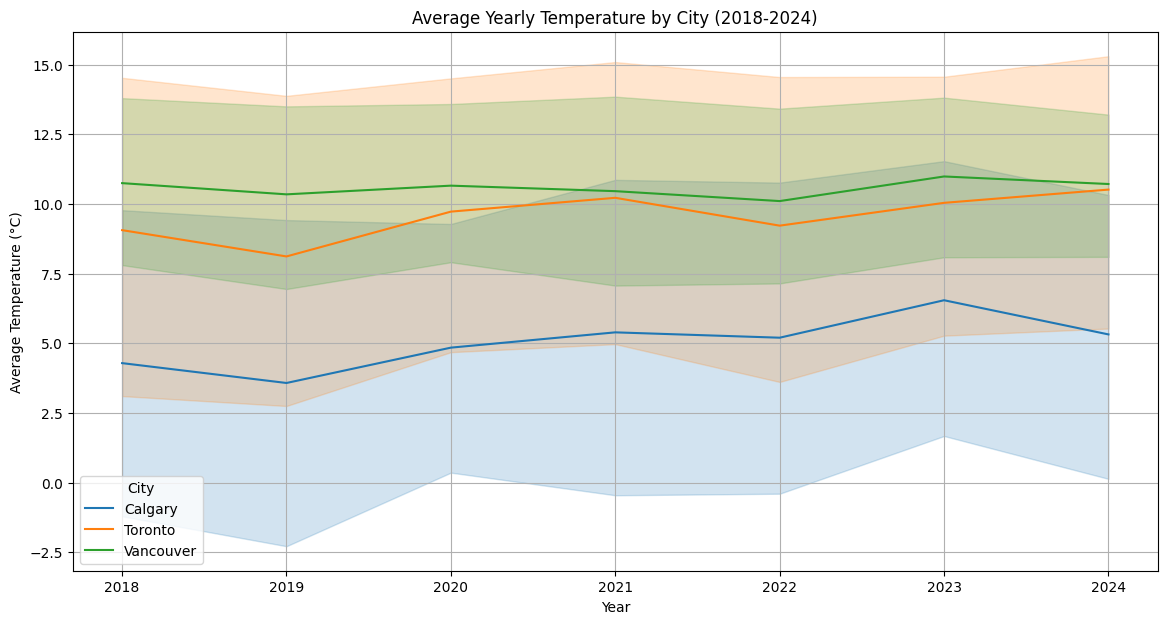

In [11]:
# 1. Average Monthly Temperature by City Over Time (using monthly data)
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_weather, x='year', y='Avg_Mean_Temp', hue='city')
plt.title('Average Yearly Temperature by City (2018-2024)')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.xticks(monthly_weather['year'].unique())
plt.legend(title='City')
plt.grid(True)
plt.show()

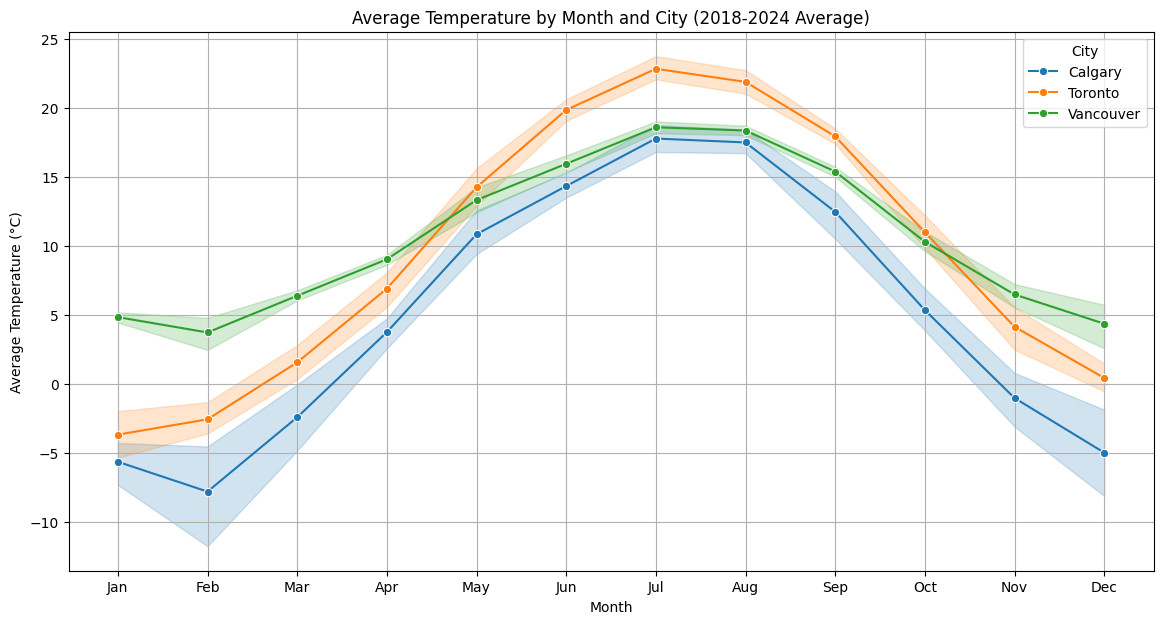

In [12]:
# 2. Monthly pattern of average temperature for each city (using monthly data)
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_weather, x='month', y='Avg_Mean_Temp', hue='city', marker='o')
plt.title('Average Temperature by Month and City (2018-2024 Average)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='City')
plt.grid(True)
plt.show()

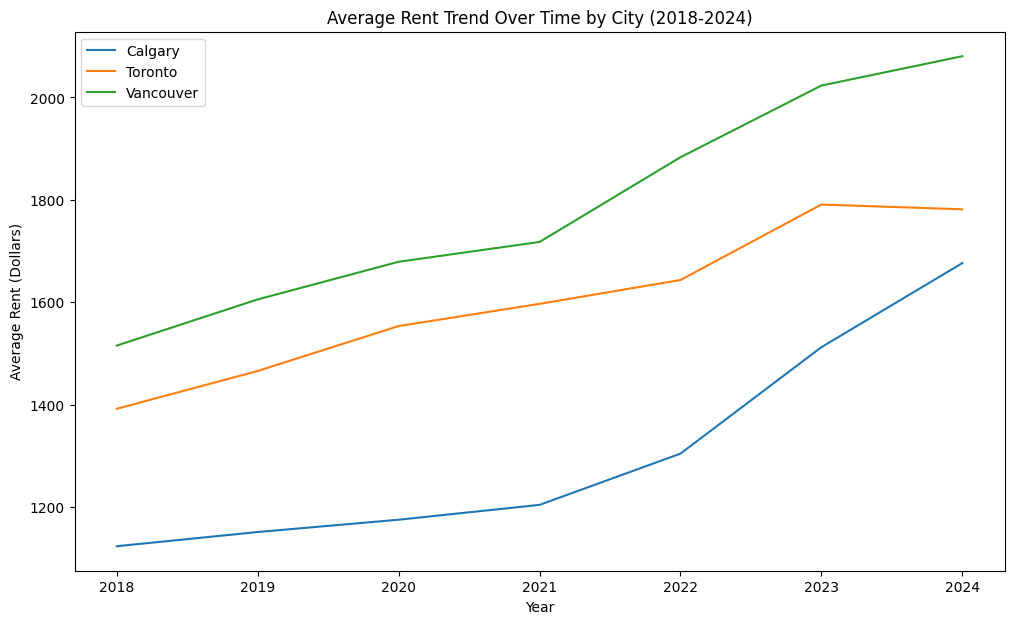

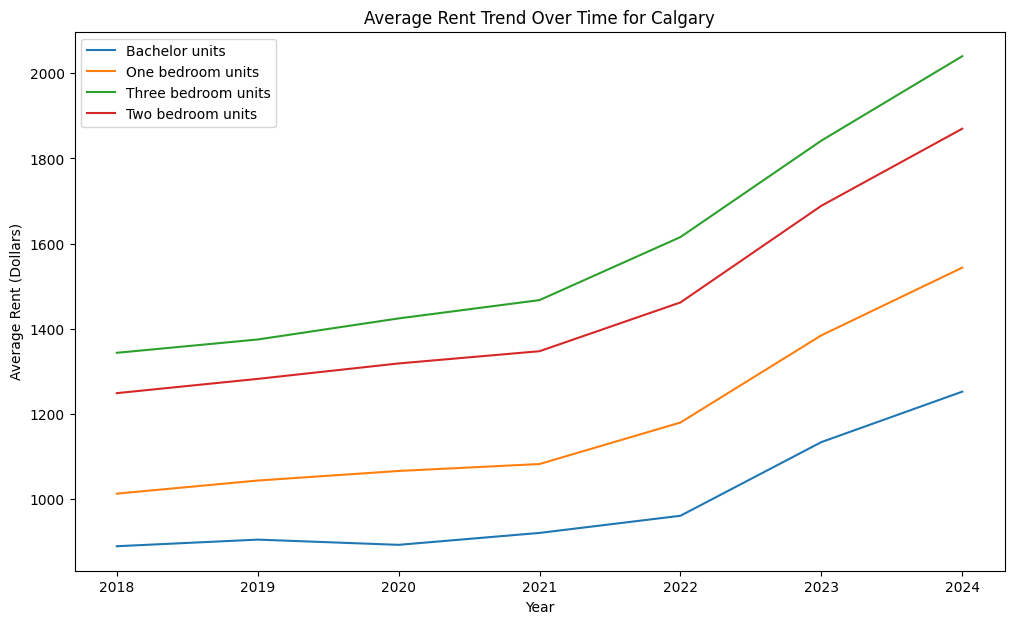

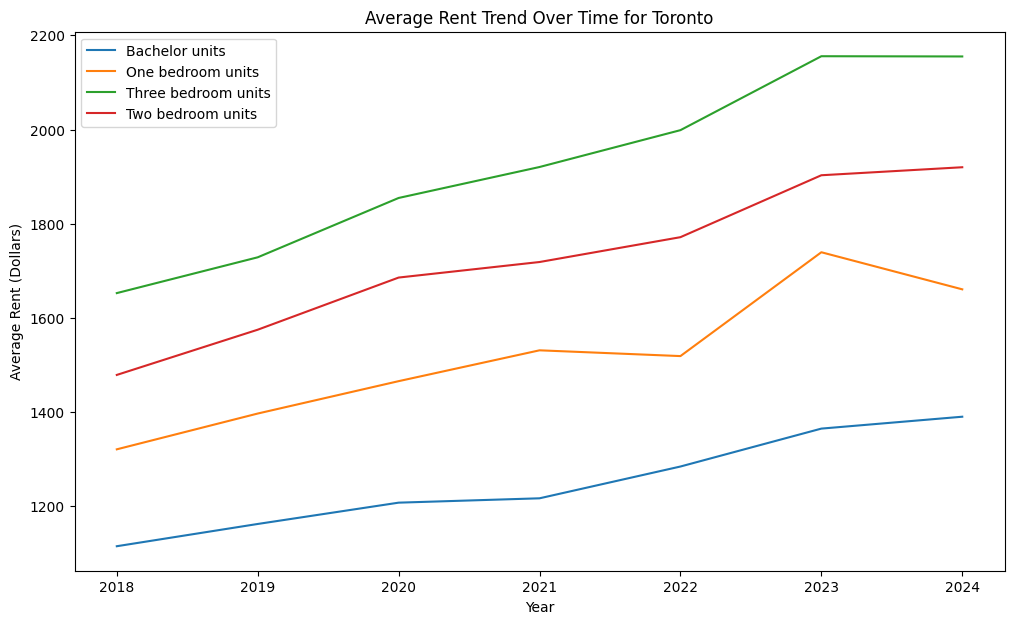

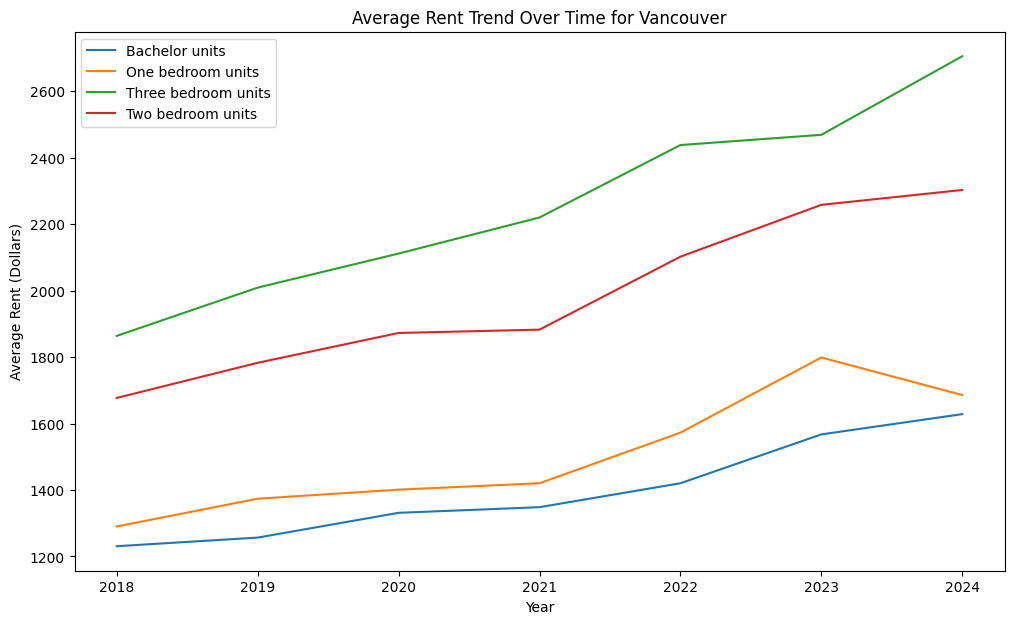

In [13]:
# 3. Visualize rent over time
# Group by GEO and REF_DATE for overall city trends
rent_trend_city = df_combined2.groupby(['city', 'year'])['VALUE'].mean().reset_index()

# Plot overall rent trend by city
plt.figure(figsize=(12, 7))
for city in rent_trend_city['city'].unique():
    city_data = rent_trend_city[rent_trend_city['city'] == city]
    plt.plot(city_data['year'], city_data['VALUE'], label=city)
plt.title('Average Rent Trend Over Time by City (2018-2024)')
plt.xlabel('Year')
plt.ylabel('Average Rent (Dollars)')
plt.legend()
plt.show()
plt.close()


# Group by GEO, Type of unit, and REF_DATE for unit type trends within cities
rent_trend_unit_type = df_combined2.groupby(['city', 'Type of unit', 'year'])['VALUE'].mean().reset_index()

# Plot rent trend by unit type for each city
for city in rent_trend_unit_type['city'].unique():
    city_data = rent_trend_unit_type[rent_trend_unit_type['city'] == city]
    plt.figure(figsize=(12, 7))
    for unit_type in city_data['Type of unit'].unique():
        unit_type_data = city_data[city_data['Type of unit'] == unit_type]
        plt.plot(unit_type_data['year'], unit_type_data['VALUE'], label=unit_type)

    plt.title(f'Average Rent Trend Over Time for {city}')
    plt.xlabel('Year')
    plt.ylabel('Average Rent (Dollars)')
    plt.legend()
    plt.show()
    plt.close()
    

In [14]:
#4. Extreme weather impacts and precipitation by city (2023)

df_2023 = df_combined[df_combined['year'] == 2023].copy()

weather_impacts_2023 = df_2023.groupby('city').agg(
    Total_Precip_mm=('Total_Precip_mm', 'sum'),
    Avg_Dwelling_Damage_Percent=('avg_dwelling_damage_percent', 'mean'),
    Avg_Poor_Air_Quality_Percent=('avg_poor_air_quality_percent', 'mean'),
    Avg_Heavy_Rain_Impact_Percent=('avg_heavy_rain_impact_percent', 'mean')
).reset_index()

weather_impacts_melted = weather_impacts_2023.melt(
    id_vars='city',
    value_vars=['Avg_Dwelling_Damage_Percent', 'Avg_Poor_Air_Quality_Percent', 'Avg_Heavy_Rain_Impact_Percent'],
    var_name='Metric',
    value_name='Value'
)

fig = px.bar(weather_impacts_melted,
             x='city',
             y='Value',
             color='Metric',
             title='Aggregated Extreme Weather Impacts')
fig.show()

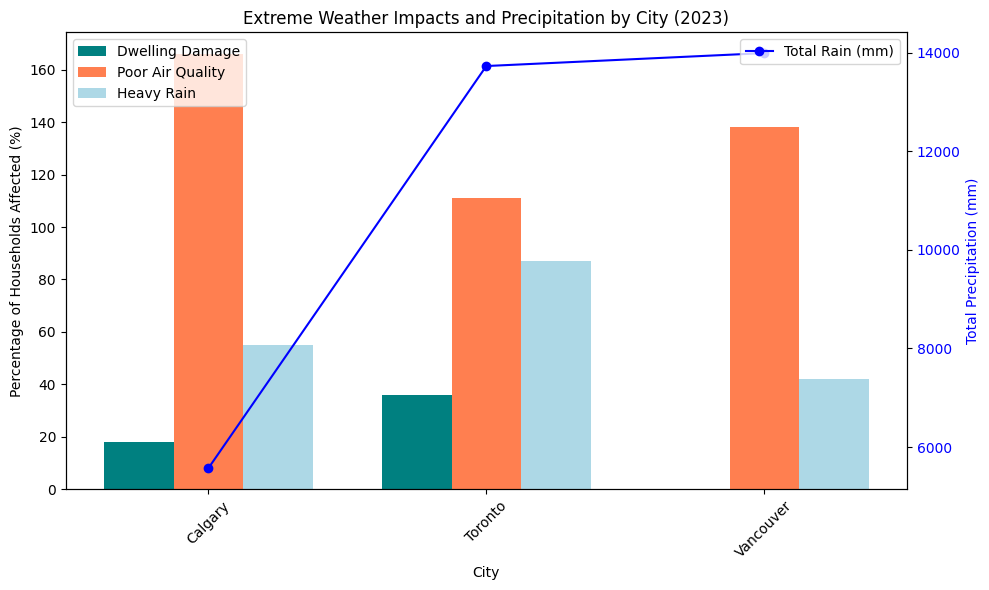

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data
df_2023 = df_combined[df_combined['year'] == 2023].copy()

weather_impacts_2023 = df_2023.groupby('city').agg(
    total_rain_mm=('Total_Precip_mm', 'sum'),
    dwelling_damage_percent=('avg_dwelling_damage_percent', 'mean'),
    poor_air_quality_percent=('avg_poor_air_quality_percent', 'mean'),
    heavy_rain_percent=('avg_heavy_rain_impact_percent', 'mean')
).reset_index()

# For plotting
plot_data = weather_impacts_2023.copy()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

index = np.arange(len(plot_data['city']))
bar_width = 0.25

# Bar plots for percentages
ax1.bar(index - bar_width, plot_data['dwelling_damage_percent'], bar_width, label='Dwelling Damage', color='teal')
ax1.bar(index, plot_data['poor_air_quality_percent'], bar_width, label='Poor Air Quality', color='coral')
ax1.bar(index + bar_width, plot_data['heavy_rain_percent'], bar_width, label='Heavy Rain', color='lightblue')

ax1.set_xlabel('City')
ax1.set_ylabel('Percentage of Households Affected (%)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Extreme Weather Impacts and Precipitation by City (2023)')
ax1.set_xticks(index)
ax1.set_xticklabels(plot_data['city'], rotation=45)

# Line plot for precipitation
ax2 = ax1.twinx()
ax2.plot(index, plot_data['total_rain_mm'], 'o-', label='Total Rain (mm)', color='blue')
ax2.set_ylabel('Total Precipitation (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('hes_impacts_with_precip_2023.png')
plt.show()
plt.close()

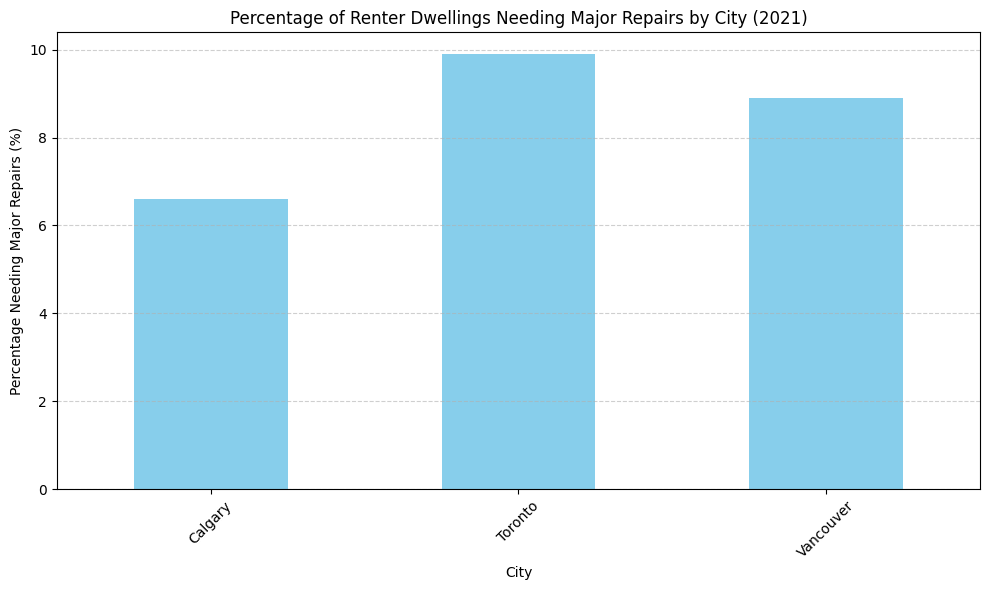

In [16]:
# Bar Plot: Percentage of Renter Dwellings Needing Major Repairs in 2021 by City
plt.figure(figsize=(10, 6))

# Filter data for 2021
df_2021 = df_combined[df_combined['year'] == 2021]

# Group by city and calculate the mean percentage
repairs_2021 = df_2021.groupby('city')['renter_major_repairs_percent'].mean()

# Plot the bar chart
repairs_2021.plot(kind='bar', color='skyblue')

plt.title('Percentage of Renter Dwellings Needing Major Repairs by City (2021)')
plt.xlabel('City')
plt.ylabel('Percentage Needing Major Repairs (%)')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

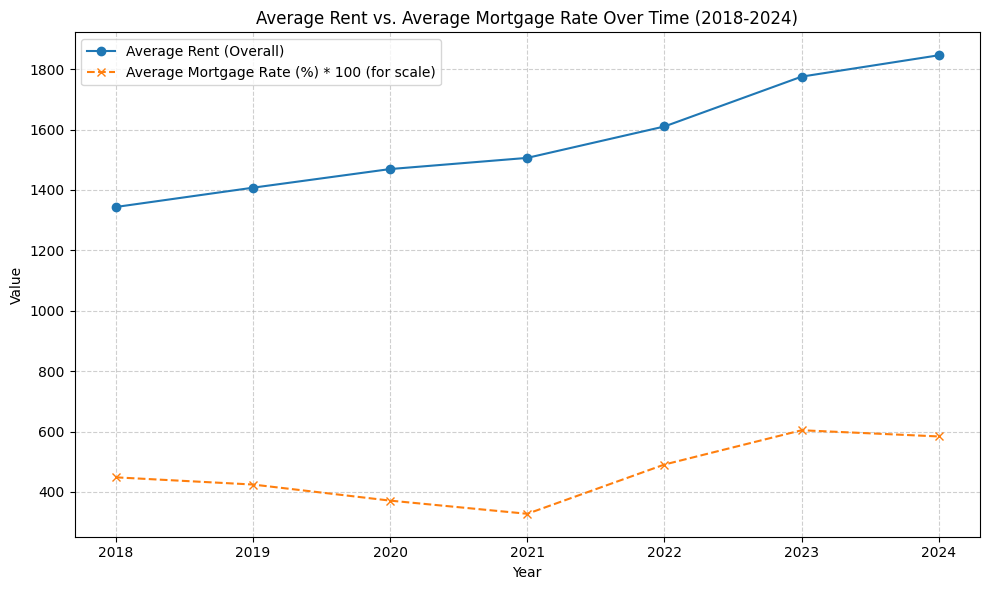

In [17]:
# Plot: Average Rent vs. Average Mortgage Rate (time-series, updated with full data)
plt.figure(figsize=(10, 6))
df_annual_summary = df_combined.groupby('year').agg(
    avg_rent=('VALUE', 'mean'),
    avg_mortgage_rate=('mortgage_rate', 'mean')
).reset_index()

plt.plot(df_annual_summary['year'], df_annual_summary['avg_rent'], marker='o', label='Average Rent (Overall)')
# Scale mortgage rate for visual comparison on the same axis (e.g., *100 to bring to a similar magnitude as rent)
plt.plot(df_annual_summary['year'], df_annual_summary['avg_mortgage_rate'] * 100, marker='x', linestyle='--', label='Average Mortgage Rate (%) * 100 (for scale)')
plt.title('Average Rent vs. Average Mortgage Rate Over Time (2018-2024)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(df_annual_summary['year'])
plt.tight_layout()
plt.show()
plt.close()

In [18]:
plot_data = df_combined[df_combined['year'] == 2023].groupby('city').agg(
    Avg_Dwelling_Damage_Percent=('avg_dwelling_damage_percent', 'mean')
).reset_index()

plot_data_melted = plot_data.melt(
    id_vars='city',
    value_vars=['Avg_Dwelling_Damage_Percent'],
    var_name='Metric',
    value_name='Value'
)
fig = px.bar(plot_data_melted,
             x='city',
             y='Value',
             color='Metric',
             title='Dwelling Damage % by City (2023)')
fig.show()


In [19]:
df_monthly_avg_rent = df_combined.groupby(['city', 'year', 'month'])['VALUE'].mean().reset_index()
df_monthly_avg_rent['Date'] = pd.to_datetime(df_monthly_avg_rent[['year', 'month']].assign(day=1))

In [20]:
fig = px.line(df_monthly_avg_rent,
              x='Date',
              y='VALUE',
              color='city',
              title='Average Rent Trend Over Time by City')
fig.show()

In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_monthly_avg = df_combined.groupby(['city', 'year', 'month']).agg(
    Avg_Rent=('VALUE', 'mean'),
    Avg_Max_Temp=('Avg_Max_Temp', 'mean')
).reset_index()

df_monthly_avg['Date'] = pd.to_datetime(df_monthly_avg[['year', 'month']].assign(day=1))

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])


# Add Temperature traces on the secondary y-axis
for city in df_monthly_avg['city'].unique():
    city_data = df_monthly_avg[df_monthly_avg['city'] == city]
    fig.add_trace(
        go.Scatter(x=city_data['Date'], y=city_data['Avg_Max_Temp'], mode='lines', name=f'{city} Avg Max Temp', yaxis='y2'),
        secondary_y=True,
    )

# Add figure title
fig.update_layout(
    title_text='Average Max Temperature Over Time by City'
)

# Set x-axis title
fig.update_xaxes(title_text='Date')

# Set y-axes titles

fig.update_yaxes(title_text='Average Max Temp (°C)', secondary_y=True)

fig.show()

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_monthly_agg = df_combined.groupby(['city', 'year', 'month']).agg(
    Avg_Rent=('VALUE', 'mean'),
    Total_Snow_cm=('Total_Snow_cm', 'sum')
).reset_index()

df_monthly_agg['Date'] = pd.to_datetime(df_monthly_agg[['year', 'month']].assign(day=1))

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])


# Add Total Snow traces on the secondary y-axis
for city in df_monthly_agg['city'].unique():
    city_data = df_monthly_agg[df_monthly_agg['city'] == city]
    fig.add_trace(
        go.Scatter(x=city_data['Date'], y=city_data['Total_Snow_cm'], mode='lines', name=f'{city} Total Snow', yaxis='y2'),
        secondary_y=True,
    )

# Add figure title
fig.update_layout(
    title_text='Total Snowfall Over Time by City'
)

# Set x-axis title
fig.update_xaxes(title_text='Date')

# Set y-axes titles

fig.update_yaxes(title_text='Total Snow (cm)', secondary_y=True)

fig.show()

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_monthly_agg = df_combined.groupby(['city', 'year', 'month']).agg(
    Avg_Rent=('VALUE', 'mean'),
    Total_Precip_mm=('Total_Precip_mm', 'sum')
).reset_index()

df_monthly_agg['Date'] = pd.to_datetime(df_monthly_agg[['year', 'month']].assign(day=1))

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])


# Add Total Precipitation traces on the secondary y-axis
for city in df_monthly_agg['city'].unique():
    city_data = df_monthly_agg[df_monthly_agg['city'] == city]
    fig.add_trace(
        go.Scatter(x=city_data['Date'], y=city_data['Total_Precip_mm'], mode='lines', name=f'{city} Total Precip', yaxis='y2'),
        secondary_y=True,
    )

# Add figure title
fig.update_layout(
    title_text='Total Precipitation Over Time by City'
)

# Set x-axis title
fig.update_xaxes(title_text='Date')

# Set y-axes titles

fig.update_yaxes(title_text='Total Precipitation (mm)', secondary_y=True)

fig.show()

In [24]:
yearly_temp_avg = df_combined.groupby(['city', 'year']).agg(
    Avg_Max_Temp=('Avg_Max_Temp', 'mean'),
    Avg_Min_Temp=('Avg_Min_Temp', 'mean')
).reset_index()

yearly_temp_avg['Avg_Temp'] = (yearly_temp_avg['Avg_Max_Temp'] + yearly_temp_avg['Avg_Min_Temp']) / 2

fig = px.line(yearly_temp_avg,
              x='year',
              y='Avg_Temp',
              color='city',
              title='Average Yearly Temperature Trend by City (2018-2024)')
fig.show()

In [25]:
yearly_precip_sum = df_combined.groupby(['city', 'year'])['Total_Precip_mm'].sum().reset_index()

fig = px.line(yearly_precip_sum,
              x='year',
              y='Total_Precip_mm',
              color='city',
              title='Total Yearly Precipitation by City (2018-2024)')
fig.show()

In [26]:
monthly_avg_temp = df_combined.groupby(['city', 'month']).agg(
    Avg_Max_Temp=('Avg_Max_Temp', 'mean'),
    Avg_Min_Temp=('Avg_Min_Temp', 'mean')
).reset_index()

monthly_avg_temp['Avg_Temp_Monthly'] = (monthly_avg_temp['Avg_Max_Temp'] + monthly_avg_temp['Avg_Min_Temp']) / 2

fig = px.line(monthly_avg_temp,
              x='month',
              y='Avg_Temp_Monthly',
              color='city',
              title='Average Temperature by Month and City (2018-2024 Average)')
fig.show()

In [27]:
vancouver_area_violations = vancouver_issues.groupby('geolocalarea')['violation_rate'].mean().reset_index()
vancouver_area_violations = vancouver_area_violations.sort_values('violation_rate', ascending=False)

fig = px.bar(vancouver_area_violations,
             x='geolocalarea',
             y='violation_rate',
             title='Average Violation Rate by Geo Local Area in Vancouver')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [28]:
vancouver_units_violations = vancouver_issues.groupby('totalunits')['violation_rate'].mean().reset_index()
vancouver_units_violations = vancouver_units_violations.sort_values('totalunits')

fig = px.line(vancouver_units_violations,
              x='totalunits',
              y='violation_rate',
              title='Average Violation Rate vs. Total Units in Vancouver')
fig.show()

In [29]:
mortgage_rate_trend = df_combined.groupby(['year', 'month'])['mortgage_rate'].mean().reset_index()
mortgage_rate_trend['Date'] = pd.to_datetime(mortgage_rate_trend[['year', 'month']].assign(day=1))

fig = px.line(mortgage_rate_trend,
              x='Date',
              y='mortgage_rate',
              title='Average Mortgage Rate Over Time')
fig.show()

In [30]:
avg_max_temp_by_city = df_combined.groupby('city')['Avg_Max_Temp'].mean().reset_index()

fig = px.bar(avg_max_temp_by_city,
             x='city',
             y='Avg_Max_Temp',
             title='Average Max Temperature by City')
fig.show()

In [31]:
df_2023_prices = df_combined[df_combined['year'] == 2023].copy()

avg_prices_by_city_2023 = df_2023_prices.groupby('city')['avg_house_price'].mean().reset_index()

fig = px.bar(avg_prices_by_city_2023,
             x='city',
             y='avg_house_price',
             title='Average House Prices by City (2023)')
fig.show()

✅ Created 'Date' column.

--- 4.1 Housing Affordability Prediction (Average Rent) ---
Random Forest (Rent) → RMSE: 328.24 | R²: 0.38 | CV R²: 0.32


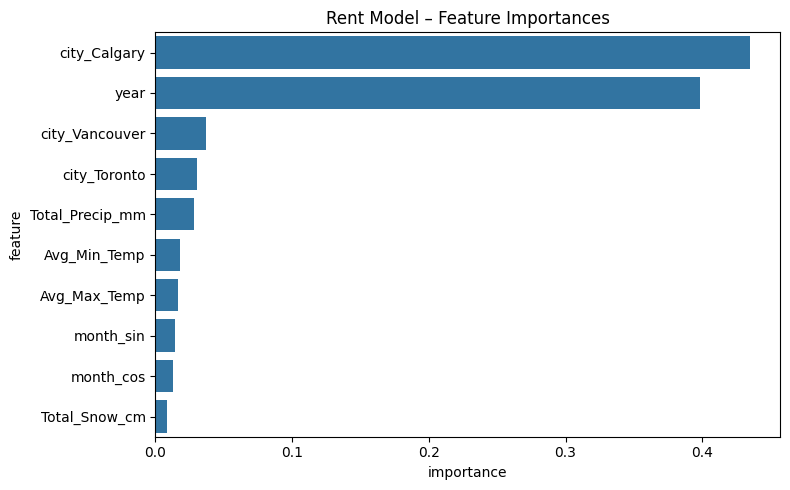

✅ Rent model saved.

--- 4.3 Rental Housing Quality: Dwelling Damage (Classification) ---
Gradient Boosting → CV Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        77

    accuracy                           1.00       116
   macro avg       1.00      1.00      1.00       116
weighted avg       1.00      1.00      1.00       116

Confusion Matrix:
 [[39  0]
 [ 0 77]]
✅ Dwelling damage model saved.

--- 4.4 Correlation Analysis ---


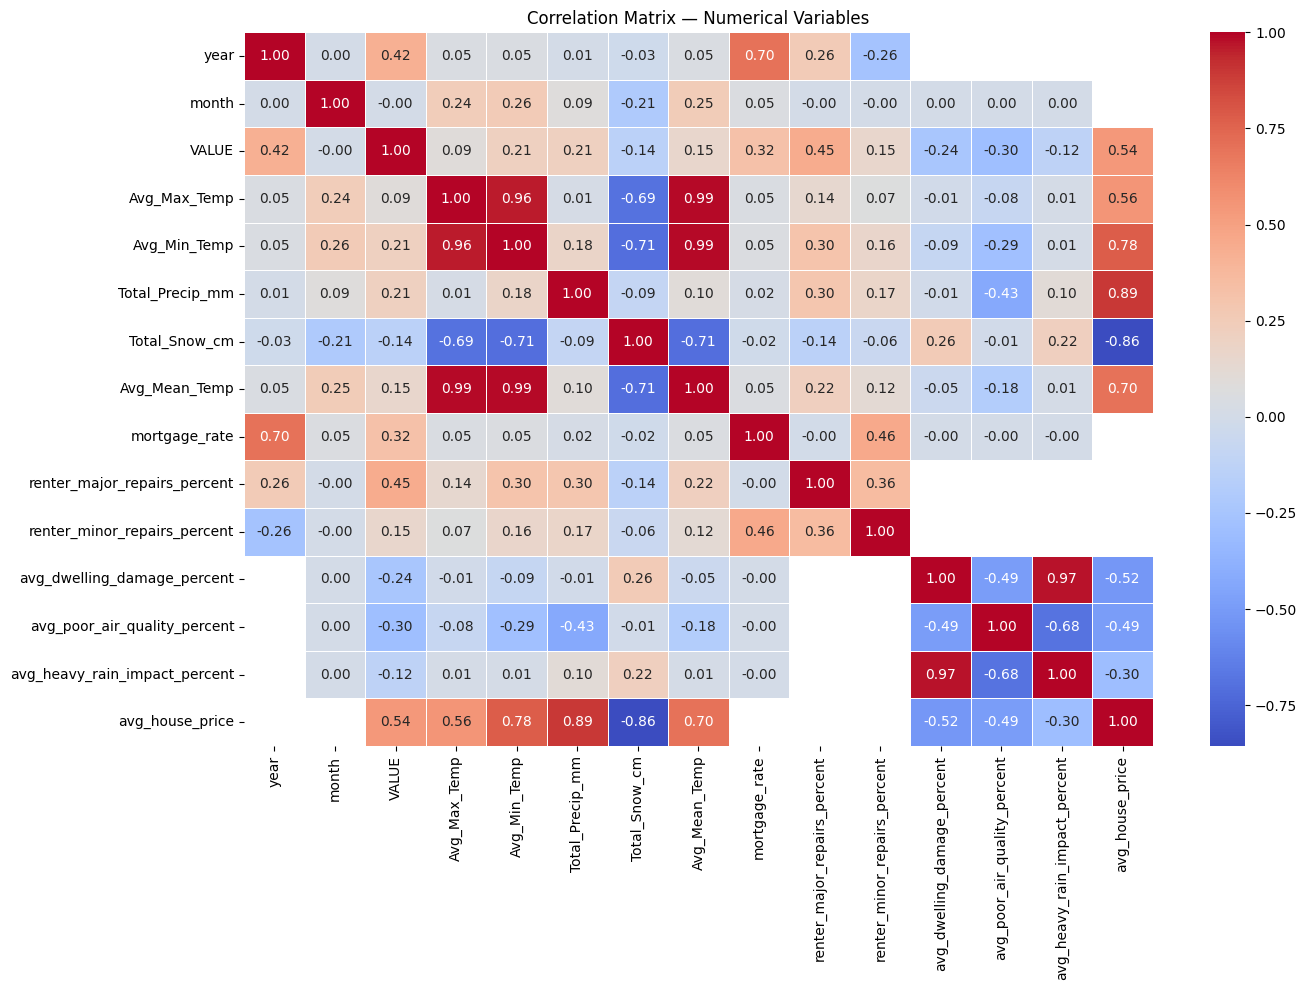


--- 4.5 Geographic Vulnerability (Clustering) ---
           Cluster
city              
Calgary          1
Toronto          0
Vancouver        2


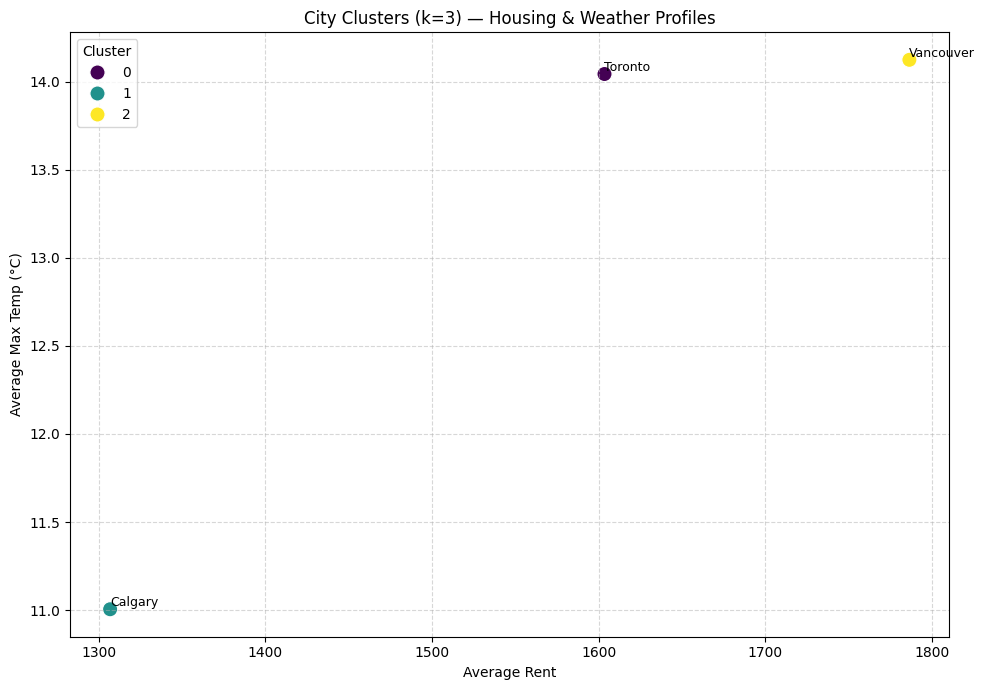


--- 4.6 Time-Series Forecasting (Average Rent) ---

City: Toronto
✅ ARIMA model for Toronto saved.


19:01:57 - cmdstanpy - INFO - Chain [1] start processing
19:01:59 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model for Toronto saved.


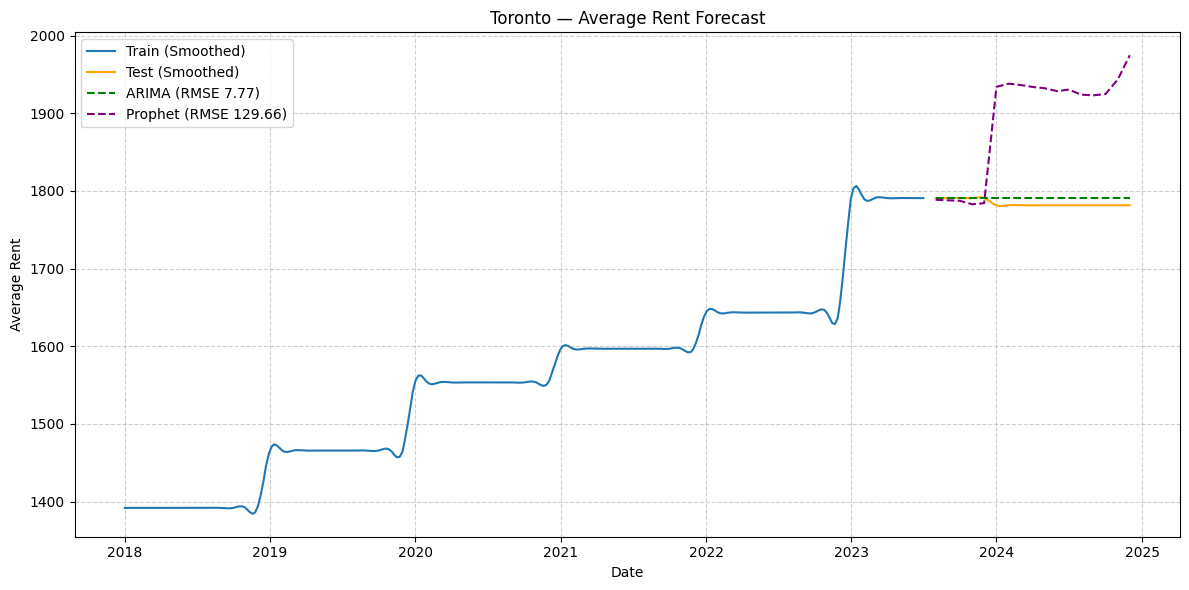

19:01:59 - cmdstanpy - INFO - Chain [1] start processing



City: Calgary
✅ ARIMA model for Calgary saved.


19:02:00 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model for Calgary saved.


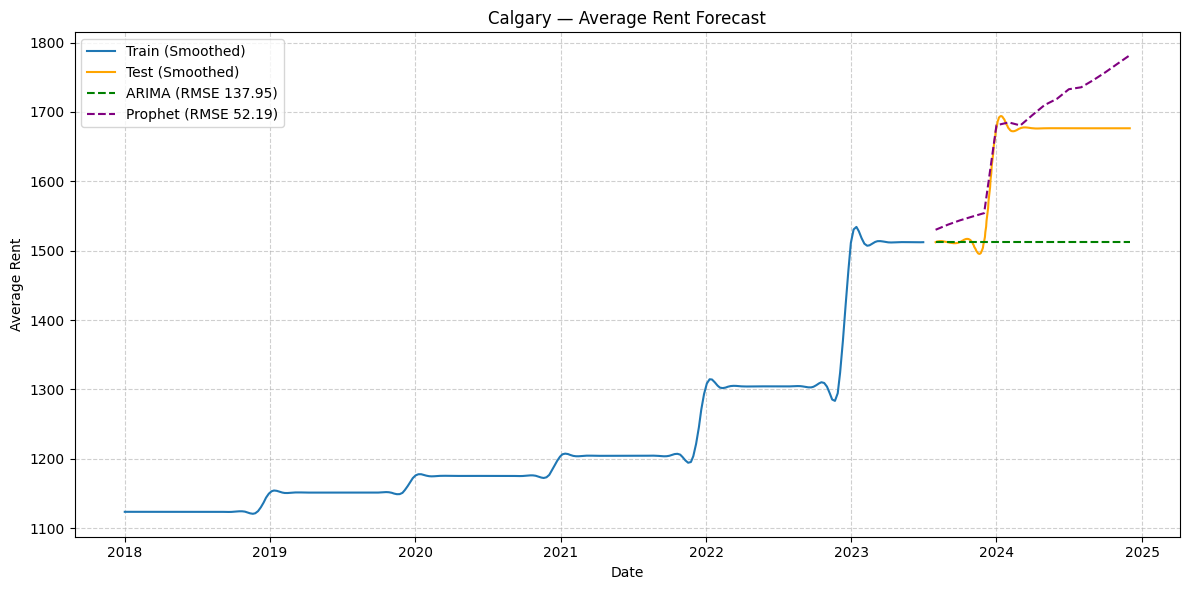

19:02:01 - cmdstanpy - INFO - Chain [1] start processing



City: Vancouver
✅ ARIMA model for Vancouver saved.


19:02:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model for Vancouver saved.


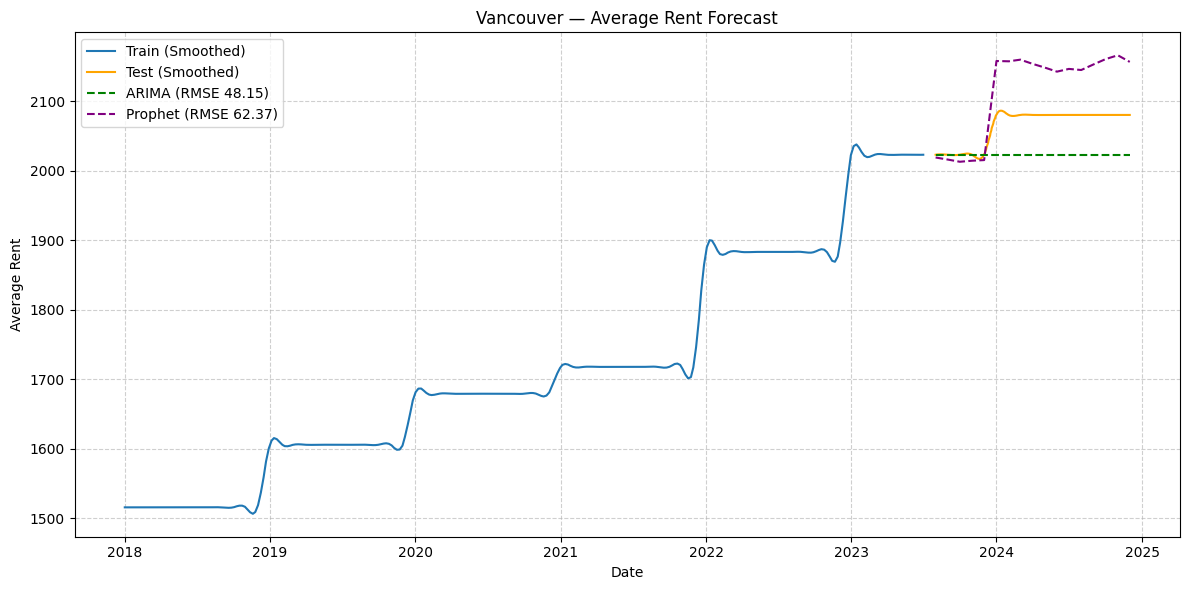


Forecasting RMSE Summary:
        city  ARIMA_RMSE  Prophet_RMSE
1    Calgary  137.945092     52.185577
2  Vancouver   48.152131     62.372807
0    Toronto    7.771554    129.664078

✅ All analyses complete. Models are saved in 'trained_models/' directory.


In [32]:
"""
Canada Housing & Weather Impact Analysis - Predictive Modeling (Modular)
- Rent model (no mortgage rate)
- Dwelling damage classification
- Correlation heatmap
- City clustering
- Time-series forecasting (Prophet)
- Models saved for later use
"""

import warnings
warnings.filterwarnings('ignore')

# --- Core ---
import pandas as pd
import numpy as np
import os

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utils ---
from datetime import datetime
from scipy.interpolate import interp1d

# --- ML / Preprocessing ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Models ---
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier

# --- Metrics ---
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

# --- Imbalance ---
from imblearn.over_sampling import SMOTE

# --- Clustering ---
from sklearn.cluster import KMeans

# --- Time Series ---
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

# --- Joblib for saving models ---
import joblib

# =============================================================================
# Configuration
# =============================================================================
SEED = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
PLOT_FIGSIZE = (12, 6)
TOP_N_FEATURES = 10
MODEL_DIR = "trained_models"

np.random.seed(SEED)
os.makedirs(MODEL_DIR, exist_ok=True)

# =============================================================================
# Utilities
# =============================================================================
def create_date_column(df):
    if 'Date' not in df.columns:
        df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))
        print("✅ Created 'Date' column.")
    return df


def build_preprocessor(numerical_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )


def evaluate_regression(pipe, X_train, y_train, X_test, y_test, cv_folds=CV_FOLDS, label=""):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv_folds, scoring='r2').mean()
    print(f"{label} → RMSE: {rmse:.2f} | R²: {r2:.2f} | CV R²: {cv_r2:.2f}")
    return rmse, r2, cv_r2, y_pred


def evaluate_classification(model, X_train, y_train, X_test, y_test, cv_folds=CV_FOLDS, label=""):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='accuracy').mean()
    print(f"{label} → CV Accuracy: {cv_acc:.2f}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return cv_acc, y_pred


def plot_feature_importances(importances, feature_names, top_n=TOP_N_FEATURES, title="Top Feature Importances"):
    fi = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=fi)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 4.1 Housing Affordability Prediction (Average Rent)
# =============================================================================
def run_rent_prediction(df):
    print("\n--- 4.1 Housing Affordability Prediction (Average Rent) ---")
    target = 'VALUE'
    base_features = ['Avg_Max_Temp', 'Avg_Min_Temp', 'Total_Precip_mm', 'Total_Snow_cm', 'year', 'month', 'city']

    data = df.dropna(subset=[target] + base_features).copy()
    if data.empty:
        print("⚠ No data available for rent model.")
        return None

    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    data.drop(columns='month', inplace=True)

    num_features = ['Avg_Max_Temp', 'Avg_Min_Temp', 'Total_Precip_mm', 'Total_Snow_cm', 'year', 'month_sin', 'month_cos']
    cat_features = ['city']
    preprocessor = build_preprocessor(num_features, cat_features)

    X = data[num_features + cat_features]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)

    # Random Forest pipeline
    rf_pipe = Pipeline([('preprocessor', preprocessor),
                        ('regressor', RandomForestRegressor(random_state=SEED))])
    evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test, label="Random Forest (Rent)")

    rf_pipe.fit(X_train, y_train)
    ohe = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
    ohe_names = list(ohe.get_feature_names_out(cat_features))
    all_names = num_features + ohe_names
    importances = rf_pipe.named_steps['regressor'].feature_importances_
    plot_feature_importances(importances, all_names, title="Rent Model – Feature Importances")

    # Save model
    joblib.dump(rf_pipe, os.path.join(MODEL_DIR, "rent_model_pipeline.pkl"))
    print("✅ Rent model saved.")
    return rf_pipe


# =============================================================================
# 4.3 Dwelling Damage Classification
# =============================================================================
def run_dwelling_damage(df):
    print("\n--- 4.3 Rental Housing Quality: Dwelling Damage (Classification) ---")
    target_raw = 'avg_dwelling_damage_percent'
    features = ['Total_Precip_mm', 'Total_Snow_cm', 'Avg_Max_Temp', 'Avg_Min_Temp', 'year', 'city']

    data = df.dropna(subset=[target_raw]).copy()
    if data.empty:
        print("⚠ No data for dwelling damage.")
        return None, None

    data['has_damage'] = (data[target_raw] > 0).astype(int)
    num_features = ['Total_Precip_mm', 'Total_Snow_cm', 'Avg_Max_Temp', 'Avg_Min_Temp', 'year']
    cat_features = ['city']
    preprocessor = build_preprocessor(num_features, cat_features)

    X = data[num_features + cat_features]
    y = data['has_damage']
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=TEST_SIZE, random_state=SEED)

    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    smote = SMOTE(random_state=SEED)
    X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

    model = GradientBoostingClassifier(random_state=SEED)
    evaluate_classification(model, X_train_res, y_train_res, X_test_proc, y_test, label="Gradient Boosting")
    model.fit(X_train_res, y_train_res)

    # Save preprocessor + model
    joblib.dump(preprocessor, os.path.join(MODEL_DIR, "dwelling_damage_preprocessor.pkl"))
    joblib.dump(model, os.path.join(MODEL_DIR, "dwelling_damage_model.pkl"))
    print("✅ Dwelling damage model saved.")
    return preprocessor, model


# =============================================================================
# 4.4 Correlation Analysis
# =============================================================================
def run_correlation(df):
    print("\n--- 4.4 Correlation Analysis ---")
    num_df = df.select_dtypes(include=np.number)
    num_df = num_df.loc[:, num_df.nunique() > 1]
    if num_df.empty:
        print("⚠ No numeric data for correlation.")
        return
    plt.figure(figsize=(14, 10))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
    plt.title("Correlation Matrix — Numerical Variables")
    plt.tight_layout()
    plt.show()


# =============================================================================
# 4.5 Clustering
# =============================================================================
def run_clustering(df):
    print("\n--- 4.5 Geographic Vulnerability (Clustering) ---")
    agg = df.groupby('city').agg(
        Avg_Rent=('VALUE', 'mean'),
        Avg_House_Price=('avg_house_price', 'mean'),
        Avg_Precip=('Total_Precip_mm', 'mean'),
        Avg_Snow=('Total_Snow_cm', 'mean'),
        Avg_Max_Temp=('Avg_Max_Temp', 'mean'),
        Avg_Min_Temp=('Avg_Min_Temp', 'mean')
    ).dropna()
    if agg.empty or len(agg) < 2:
        print("⚠ Not enough city-level data for clustering.")
        return

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(agg)
    k = min(3, len(agg))
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    agg['Cluster'] = kmeans.fit_predict(X_scaled)

    print(agg[['Cluster']])
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=agg, x='Avg_Rent', y='Avg_Max_Temp', hue='Cluster', s=120, palette='viridis')
    for city, row in agg.iterrows():
        plt.text(row['Avg_Rent'], row['Avg_Max_Temp'], city, fontsize=9, ha='left', va='bottom')
    plt.title(f"City Clusters (k={k}) — Housing & Weather Profiles")
    plt.xlabel("Average Rent")
    plt.ylabel("Average Max Temp (°C)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 4.6 Forecasting
# =============================================================================
def _smooth_series(dates, values, method='cubic', points=300):
    if len(dates) < 2:
        return dates, values
    kind = method if len(dates) >= 4 else 'linear'
    x_num = dates.map(pd.Timestamp.toordinal)
    f_interp = interp1d(x_num, values, kind=kind)
    x_new = np.linspace(x_num.min(), x_num.max(), points)
    smoothed_dates = [datetime.fromordinal(int(x)) for x in x_new]
    return smoothed_dates, f_interp(x_new)


def forecast_city_rent(df, city, plot=True):
    city_df = df[df['city'] == city].copy()
    if city_df.empty:
        print(f"⚠ No data for {city}")
        return None, None, None

    monthly = city_df.groupby('Date')['VALUE'].mean().reset_index()
    monthly = monthly.rename(columns={'Date': 'ds', 'VALUE': 'y'}).sort_values('ds')

    if len(monthly) < 6:
        print(f"⚠ Not enough data points ({len(monthly)}) for {city} forecasting.")
        return None, None, None

    train_size = int(len(monthly) * 0.8)
    train = monthly.iloc[:train_size]
    test = monthly.iloc[train_size:]

    results = {}

    # --- ARIMA ---
    try:
        arima_model = ARIMA(train['y'], order=(1, 1, 1))
        arima_fit = arima_model.fit()
        arima_pred = arima_fit.forecast(steps=len(test))
        rmse_arima = np.sqrt(mean_squared_error(test['y'], arima_pred))
        results['ARIMA_RMSE'] = rmse_arima
        joblib.dump(arima_fit, os.path.join(MODEL_DIR, f"arima_{city.lower().replace(' ', '_')}.pkl"))
        print(f"✅ ARIMA model for {city} saved.")
    except Exception as e:
        print(f"⚠ ARIMA failed for {city}: {e}")
        arima_fit = None

    # --- Prophet ---
    prophet = Prophet(seasonality_mode='multiplicative', changepoint_prior_scale=0.05)
    prophet.add_country_holidays(country_name='CA')
    prophet.fit(train)
    future = prophet.make_future_dataframe(periods=len(test), freq='MS')
    forecast = prophet.predict(future)
    prophet_pred = forecast['yhat'].iloc[train_size:]
    prophet_pred.index = test['ds']
    rmse_prophet = np.sqrt(mean_squared_error(test['y'], prophet_pred))
    results['Prophet_RMSE'] = rmse_prophet
    joblib.dump(prophet, os.path.join(MODEL_DIR, f"prophet_{city.lower().replace(' ', '_')}.pkl"))
    print(f"✅ Prophet model for {city} saved.")

    # --- Plot ---
    if plot:
        plt.figure(figsize=PLOT_FIGSIZE)
        sm_tr_d, sm_tr_v = _smooth_series(train['ds'], train['y'])
        sm_te_d, sm_te_v = _smooth_series(test['ds'], test['y'])
        plt.plot(sm_tr_d, sm_tr_v, label='Train (Smoothed)')
        plt.plot(sm_te_d, sm_te_v, label='Test (Smoothed)', color='orange')
        if arima_fit:
            plt.plot(test['ds'], arima_pred, '--', label=f"ARIMA (RMSE {rmse_arima:.2f})", color='green')
        plt.plot(test['ds'], prophet_pred, '--', label=f"Prophet (RMSE {rmse_prophet:.2f})", color='purple')
        plt.title(f"{city} — Average Rent Forecast")
        plt.xlabel("Date")
        plt.ylabel("Average Rent")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results, prophet, arima_fit


def run_forecasting_for_all_cities(df):
    print("\n--- 4.6 Time-Series Forecasting (Average Rent) ---")
    prophet_models = {}
    arima_models = {}
    summary = []
    for c in df['city'].dropna().unique():
        print(f"\nCity: {c}")
        res, prophet_model, arima_fit = forecast_city_rent(df, c, plot=True)
        if res:
            summary.append({'city': c, **res})
            prophet_models[c] = prophet_model
            if arima_fit:
                arima_models[c] = arima_fit
    if summary:
        print("\nForecasting RMSE Summary:")
        print(pd.DataFrame(summary).sort_values('Prophet_RMSE'))
    return prophet_models, arima_models


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    try:
        df_combined
    except NameError:
        raise ValueError("Please load df_combined before running this script.")

    df_combined = create_date_column(df_combined)

    # Run all analyses and save models
    rent_model_pipeline = run_rent_prediction(df_combined)
    dwelling_preprocessor, dwelling_model = run_dwelling_damage(df_combined)
    run_correlation(df_combined)
    run_clustering(df_combined)
    run_forecasting_for_all_cities(df_combined)

    print("\n✅ All analyses complete. Models are saved in 'trained_models/' directory.")


In [33]:
# import joblib
# import os

# # Create a directory to save the models and preprocessors
# model_dir = 'trained_models'
# os.makedirs(model_dir, exist_ok=True)

# # --- Save Housing Affordability Prediction Model (Random Forest from run_rent_prediction) ---
# if 'rent_model_pipeline' in locals():
#     joblib.dump(rent_model_pipeline, os.path.join(model_dir, 'housing_affordability_pipeline.pkl'))
#     print("✅ Housing Affordability Prediction pipeline saved.")
# else:
#     print("⚠ Housing Affordability Prediction pipeline not available to save.")

# # --- Save Dwelling Damage Prediction Model (Gradient Boosting Classifier) ---
# if 'dwelling_damage_model' in locals() and 'dwelling_damage_preprocessor' in locals():
#     joblib.dump(dwelling_damage_preprocessor, os.path.join(model_dir, 'dwelling_damage_preprocessor.pkl'))
#     joblib.dump(dwelling_damage_model, os.path.join(model_dir, 'dwelling_damage_model.pkl'))
#     print("✅ Dwelling Damage Prediction model and preprocessor saved.")
# else:
#     print("⚠ Dwelling Damage Prediction model/preprocessor not available to save.")

# # --- Save Prophet Models for Each City ---
# if 'prophet_models' in locals():
#     for city, model in prophet_models.items():
#         prophet_filename = os.path.join(model_dir, f'prophet_{city.lower().replace(" ", "_")}.pkl')
#         try:
#             joblib.dump(model, prophet_filename)
#             print(f"✅ Prophet model for {city} saved.")
#         except Exception as e:
#             print(f"⚠ Could not save Prophet model for {city}: {e}")
# else:
#     print("⚠ No Prophet models available to save.")

# print(f"\n📂 All available models and preprocessors saved to '{model_dir}' directory.")


In [34]:
df_combined.columns

Index(['city', 'Type of unit', 'year', 'month', 'VALUE', 'Avg_Max_Temp',
       'Avg_Min_Temp', 'Total_Precip_mm', 'Total_Snow_cm', 'Avg_Mean_Temp',
       'geo', 'dguid', 'uom', 'uom_id', 'scalar_factor', 'scalar_id', 'vector',
       'coordinate', 'mortgage_rate', 'decimals',
       'renter_major_repairs_percent', 'renter_minor_repairs_percent',
       'avg_dwelling_damage_percent', 'avg_poor_air_quality_percent',
       'avg_heavy_rain_impact_percent', 'avg_long_power_loss_percent',
       'avg_house_price', 'Date'],
      dtype='object')